# Additive white gaussian noise
Additive white gaussian noise (AWGN) is a very simple model for the distortion happening between a source and a receiver.

- The signal of the sender $x(n)$ and the distortion $d(n)$ are added.
- $d(n)$ is Gaussian, white noise.
- Gaussian or normal distributed corresponds to a normal distributed probability density function (pdf): $p(d)=\frac{1}{\sqrt{2\pi\sigma^2}}\cdot e^{-\frac{\left(d(n)-m\right)^2}{2\sigma^2}}$, with $m$ corresponding to the mean value of the distribution and $\sigma$ corresponds to the [standard deviation](./StandardDeviation.ipynb).
- In this context, white corresponds to a (nearly) constant power density spectrum (pds): $\left|D(f)\right|^2\approx\text{const}$. Note: The pds is only flat or nearly constant, if the mean of $d(n)$ is zero.


In [20]:
import numpy as np
import matplotlib.pyplot as plt

m = 17
s = 7
d = np.random.randn(100000) * s + m

assert np.isclose(np.mean(d), m, atol=0.1), 'error in evaluating the mean value'
assert np.isclose(np.std(d), s, atol=0.1), 'error in evaluating the standard deviation'

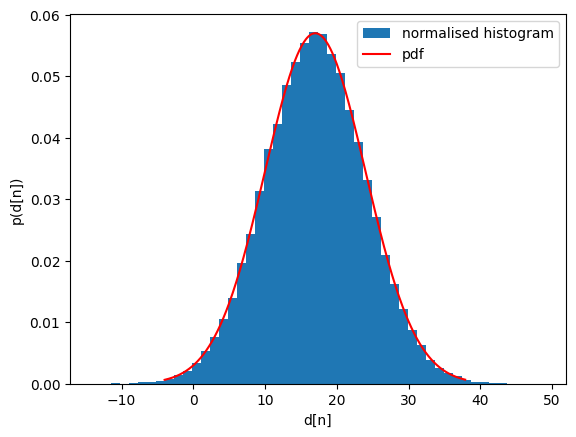

In [21]:
# show the probability density function and the histogram in time domain
d_axis = np.arange(m-3*s, m+3*s, 0.1)
pdf = (1/(s * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((d_axis - m) / s) ** 2)

plt.hist(d, bins=50, density=True, label = 'normalised histogram')
plt.plot(d_axis, pdf, 'r-', label='pdf')
plt.xlabel('d[n]')
plt.ylabel('p(d[n])')
plt.legend()
plt.show()

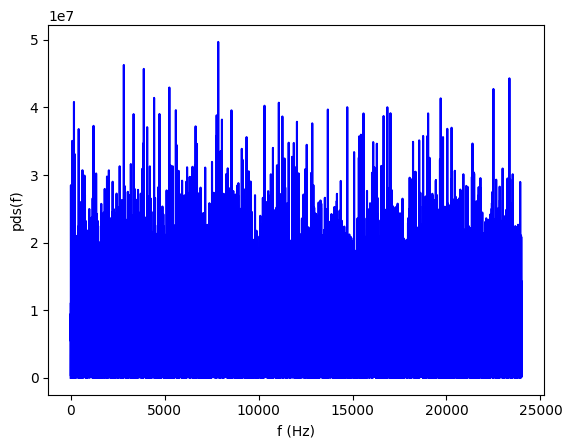

In [22]:
# show the power density spectrum (pds) in frequency domain
r = 48000
pds = np.abs(np.fft.rfft(d - np.mean(d)))**2
f_axis = np.arange(pds.shape[0])/d.shape[0]*r

plt.plot(f_axis, pds, 'b', label='power density spectrum')
plt.xlabel('f (Hz)')
plt.ylabel('pds(f)')
plt.show()